# Introduction 
## Feature Selection & Model Benchmarking: # Probability of Default Prediction
### Objective
The objective of this project is to reduce the original 23 features to the best 15 predictive features using a sequential feature selection pipeline:
1. Correlation Filter
2. Information Value (IV) Filter
3. SHAP Value Ranking

The impact of feature reduction will be evaluated using LightGBM
through Train AUC and Test AUC.
Finally, multiple classification algorithms will be tuned and compared
using the final selected 15 features. 

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier
)

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# SHAP explanation
import shap

# Information Value
import scipy.stats as stats

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42


C:\Users\HP\anaconda3\envs\cluster\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#loading the dataset into pandas Dataframe
df = pd.read_csv("default of credit card clients - Data.csv",header=1 ) 

In [5]:
#show first 5
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
df.shape

(30000, 25)

In [7]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

In [8]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [9]:
df.isnull().sum() 

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [10]:
df['default payment next month'].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

In [11]:
df['default payment next month'].value_counts(normalize=True)*100

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64

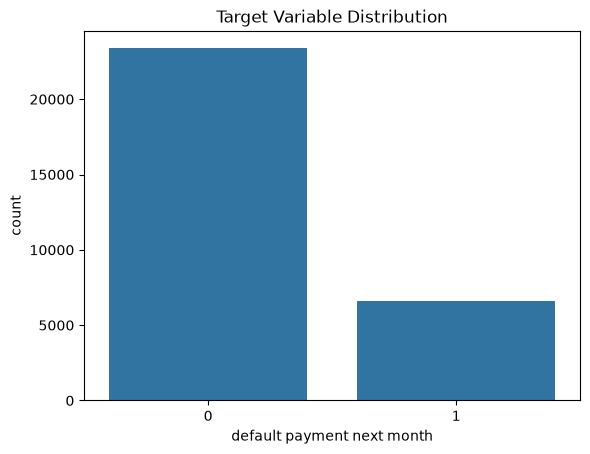

In [12]:
#Visualization
sns.countplot(
    x='default payment next month',
    data=df
)
plt.title("Target Variable Distribution")
plt.show()

**Separate Features and Target**


In [13]:
X = df.drop(
    columns=['ID','default payment next month']
)
y = df['default payment next month']


In [14]:
X.shape

(30000, 23)

**Train/Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)

(21000, 23)
(9000, 23)



## Stage 0: Baseline Model (23 Features)
At this stage, the LightGBM model is trained using all original
23 features without any feature reduction.
The obtained AUC values will be used as a reference to measure
the impact of feature selection.

**Train Baseline LightGBM Model**


In [16]:
baseline_lgbm = LGBMClassifier(
    random_state=RANDOM_STATE
)
baseline_lgbm.fit(
    X_train,
    y_train
)


[LightGBM] [Info] Number of positive: 4645, number of negative: 16355
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004723 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3262
[LightGBM] [Info] Number of data points in the train set: 21000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221190 -> initscore=-1.258742
[LightGBM] [Info] Start training from score -1.258742


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


**Calculate Train and Test AUC**

In [17]:
train_prob = baseline_lgbm.predict_proba(
    X_train
)[:,1]
test_prob = baseline_lgbm.predict_proba(
    X_test
)[:,1]
train_auc_0 = roc_auc_score(
    y_train,
    train_prob
)
test_auc_0 = roc_auc_score(
    y_test,
    test_prob
)
print("Stage 0 Train AUC:", train_auc_0)
print("Stage 0 Test AUC:", test_auc_0)

Stage 0 Train AUC: 0.8895212881311089
Stage 0 Test AUC: 0.7766093805345627


**Create Stage Results Table**


In [18]:
stage_results = pd.DataFrame({
    "Stage": [
        "Original Features"
    ],
    "Number of Features": [
        X_train.shape[1]
    ],
    "Train AUC": [
        train_auc_0
    ],
    "Test AUC": [
        test_auc_0
    ]
})
stage_results                           

,Stage,Number of Features,Train AUC,Test AUC
0,Original Features,23,0.889521,0.776609


#### Step A: Correlation Filter
Highly correlated features may contain similar information.
To reduce redundancy,
Pearson correlation is calculated using only
the training data.
A threshold of |correlation| > 0.8 is used as required.


In [19]:
corr_matrix = X_train.corr(method="pearson")
corr_matrix.head()


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
LIMIT_BAL,1.000000,0.030019,-0.213701,-0.114321,0.150665,-0.268745,-0.300524,-0.291529,-0.270330,-0.253687,...,0.284634,0.294917,0.294924,0.290908,0.192822,0.194009,0.210032,0.206549,0.225059,0.217728
SEX,0.030019,1.000000,0.007141,-0.031797,-0.092993,-0.063384,-0.071592,-0.072490,-0.064492,-0.057486,...,-0.024774,-0.020334,-0.016801,-0.017362,-0.000741,-0.006204,-0.001941,-0.000358,0.003239,-0.003829
EDUCATION,-0.213701,0.007141,1.000000,-0.142210,0.168914,0.109288,0.126302,0.118453,0.113763,0.102787,...,0.019772,0.005506,-0.003116,-0.003707,-0.032029,-0.026379,-0.038094,-0.044509,-0.036421,-0.033139
MARRIAGE,-0.114321,-0.031797,-0.142210,1.000000,-0.412734,0.021073,0.028392,0.035035,0.035573,0.036986,...,-0.025159,-0.023743,-0.026559,-0.022216,-0.009752,-0.009655,0.000083,-0.010333,-0.004612,-0.008814
AGE,0.150665,-0.092993,0.168914,-0.412734,1.000000,-0.038690,-0.050860,-0.050726,-0.048490,-0.052244,...,0.056552,0.052852,0.051736,0.052343,0.032147,0.028545,0.026337,0.026664,0.030101,0.024031


In [20]:
upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)
high_corr_pairs = []
for column in upper_triangle.columns:
    for row in upper_triangle.index:
        if abs(upper_triangle.loc[row, column]) > 0.8:
            high_corr_pairs.append(
                (
                    row,
                    column,
                    upper_triangle.loc[row, column]
                )
            )
high_corr_pairs

[('PAY_4', 'PAY_5', np.float64(0.8174107317202461)),
 ('PAY_5', 'PAY_6', np.float64(0.8133656344809543)),
 ('BILL_AMT1', 'BILL_AMT2', np.float64(0.9525064610449504)),
 ('BILL_AMT1', 'BILL_AMT3', np.float64(0.9005329783414517)),
 ('BILL_AMT2', 'BILL_AMT3', np.float64(0.9361830787707595)),
 ('BILL_AMT1', 'BILL_AMT4', np.float64(0.8634872804272309)),
 ('BILL_AMT2', 'BILL_AMT4', np.float64(0.8938935572987068)),
 ('BILL_AMT3', 'BILL_AMT4', np.float64(0.9329786981864701)),
 ('BILL_AMT1', 'BILL_AMT5', np.float64(0.8340553413008839)),
 ('BILL_AMT2', 'BILL_AMT5', np.float64(0.8624532718032484)),
 ('BILL_AMT3', 'BILL_AMT5', np.float64(0.8930010108697125)),
 ('BILL_AMT4', 'BILL_AMT5', np.float64(0.9415399755894724)),
 ('BILL_AMT1', 'BILL_AMT6', np.float64(0.8076301121838098)),
 ('BILL_AMT2', 'BILL_AMT6', np.float64(0.8339887098470203)),
 ('BILL_AMT3', 'BILL_AMT6', np.float64(0.8589533577389181)),
 ('BILL_AMT4', 'BILL_AMT6', np.float64(0.9030572801783648)),
 ('BILL_AMT5', 'BILL_AMT6', np.float64(0

In [21]:
#Display Number of Correlated Pairs
print("Number of highly correlated pairs:",len(high_corr_pairs))

Number of highly correlated pairs: 17


**Calculate Mutual Information**

In [22]:
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(
    X_train,
    y_train,
    random_state=RANDOM_STATE
)
mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Mutual Information": mi_scores
})
mi_df.sort_values(
    by="Mutual Information",
    ascending=False
)

,Feature,Mutual Information
5,PAY_0,0.074098
6,PAY_2,0.047022
7,PAY_3,0.039422
9,PAY_5,0.036203
8,PAY_4,0.031399
10,PAY_6,0.028843
17,PAY_AMT1,0.022608
19,PAY_AMT3,0.021751
18,PAY_AMT2,0.018539
20,PAY_AMT4,0.016886


**Remove Lower Predictive Features**


In [23]:
features_to_drop = set()
for feature1, feature2, corr_value in high_corr_pairs:
    mi1 = mi_df.loc[
        mi_df["Feature"] == feature1,
        "Mutual Information"
    ].values[0]
    mi2 = mi_df.loc[
        mi_df["Feature"] == feature2,
        "Mutual Information" 
        ].values[0]
    if mi1 >= mi2:
        features_to_drop.add(feature2)
    else:
        features_to_drop.add(feature1)
features_to_drop

{'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_4',
 'PAY_6'}

**Create Dataset After Step A**


In [24]:
X_train_A = X_train.drop(
    columns=features_to_drop
)
X_test_A = X_test.drop(
    columns=features_to_drop
)

Report Step A Result


In [25]:
print(
    "Original features:",
    X_train.shape[1]
)
print(
    "Removed features:",
    len(features_to_drop)
)
print(
    "Remaining features after Step A:",
    X_train_A.shape[1]
)

Original features: 23
Removed features: 7
Remaining features after Step A: 16


## Stage 1: LightGBM After Correlation Filtering
The LightGBM model is retrained using only the features remaining after
the correlation filter.
The performance is compared with the original 23-feature model

In [26]:
lgbm_A = LGBMClassifier(
    random_state=RANDOM_STATE
)
lgbm_A.fit(
    X_train_A,
    y_train
)

[LightGBM] [Info] Number of positive: 4645, number of negative: 16355
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005957 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1968
[LightGBM] [Info] Number of data points in the train set: 21000, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221190 -> initscore=-1.258742
[LightGBM] [Info] Start training from score -1.258742


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


**Calculate AUC**

In [27]:
train_prob_A = lgbm_A.predict_proba(
    X_train_A
)[:,1]
test_prob_A = lgbm_A.predict_proba(
    X_test_A
)[:,1]
train_auc_A = roc_auc_score(
    y_train,
    train_prob_A
)
test_auc_A = roc_auc_score(
    y_test,
    test_prob_A
)
print(
    "Step A Train AUC:",
    train_auc_A
)
print(
    "Step A Test AUC:",
    test_auc_A
)


Step A Train AUC: 0.8831514180624394
Step A Test AUC: 0.7740062482627094


**add step result table**

In [28]:
stage_A_result = pd.DataFrame({
    "Stage": [
        "After Correlation Filter"
    ],
    "Number of Features": [
        X_train_A.shape[1]
    ],
    "Train AUC": [
        train_auc_A
    ],
    "Test AUC": [
        test_auc_A
    ]
})
stage_results = pd.concat(
    [
        stage_results,
        stage_A_result
    ],
    ignore_index=True
)
stage_results

,Stage,Number of Features,Train AUC,Test AUC
0,Original Features,23,0.889521,0.776609
1,After Correlation Filter,16,0.883151,0.774006


## Step B: Information Value Filter
Information Value is calculated for every feature using only the training
data.
Features with IV <= 0 are removed according to the assignment requirement.

In [29]:
def calculate_iv(data, feature, target):
    temp = pd.DataFrame({
        "feature": data[feature],
        "target": target
    })
    # Calculate event and non-event distribution
    grouped = temp.groupby("feature")["target"].agg(
        ["count", "sum"]
    )
    grouped.columns = [
        "total",
        "events"
    ]
    grouped["non_events"] = (
        grouped["total"]
        -
        grouped["events"]
    )
    # Add distributions
    grouped["event_rate"] = (
        grouped["events"]
        /
        grouped["events"].sum()
    )
    grouped["non_event_rate"] = (
        grouped["non_events"]
        /
        grouped["non_events"].sum()
    )
    # Avoid division by zero
    grouped["event_rate"] = grouped["event_rate"].replace(
        0,
        0.000001
    )
    grouped["non_event_rate"] = grouped["non_event_rate"].replace(
        0,
        0.000001
    )
    # Weight of Evidence
    grouped["WOE"] = np.log(
        grouped["event_rate"]
        /
        grouped["non_event_rate"]
    )
    # Information Value
    grouped["IV"] = (
        (grouped["event_rate"] -
         grouped["non_event_rate"])
        *
        grouped["WOE"]
    )
    return grouped["IV"].sum()

**calculate for all step features**

In [30]:
iv_results = []
for feature in X_train_A.columns:
    iv = calculate_iv(
        X_train_A,
        feature,
        y_train
    )
    iv_results.append(
        [
            feature,
            iv
        ]
    )
iv_df = pd.DataFrame(
    iv_results,
    columns=[
        "Feature",
        "IV"
    ]
)
iv_df.sort_values(
    by="IV",
    ascending=False
)


,Feature,IV
9,BILL_AMT1,7.630375
10,PAY_AMT1,3.034406
11,PAY_AMT2,2.929090
12,PAY_AMT3,2.820358
13,PAY_AMT4,2.629929
15,PAY_AMT6,2.601834
14,PAY_AMT5,2.569279
5,PAY_0,0.899114
6,PAY_2,0.560348
7,PAY_3,0.423769


In [31]:
iv_drop_features = iv_df[
    iv_df["IV"] <= 0
    ]["Feature"].tolist()

iv_drop_features


[]

**creat datase**

In [32]:
X_train_B = X_train_A.drop(
    columns=iv_drop_features
)
X_test_B = X_test_A.drop(
    columns=iv_drop_features
)

document step b reduction

In [33]:
print(
    "Features before IV filtering:",
    X_train_A.shape[1]
)
print(
    "Features removed by IV:",
    len(iv_drop_features)
)
print(
    "Features after IV filtering:",
    X_train_B.shape[1]
)

Features before IV filtering: 16
Features removed by IV: 0
Features after IV filtering: 16


## Stage 2: LightGBM After Information Value Filtering
The LightGBM model is retrained using the features remaining after
the Information Value filter.
The performance is compared with previous feature selection stages.

In [34]:
lgbm_B = LGBMClassifier(
    random_state=RANDOM_STATE
)
lgbm_B.fit(
    X_train_B,
    y_train
)

[LightGBM] [Info] Number of positive: 4645, number of negative: 16355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000754 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1968
[LightGBM] [Info] Number of data points in the train set: 21000, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221190 -> initscore=-1.258742
[LightGBM] [Info] Start training from score -1.258742


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


**calculate and train test auc**

In [35]:
train_prob_B = lgbm_B.predict_proba(
    X_train_B
)[:,1]
test_prob_B = lgbm_B.predict_proba(
    X_test_B
)[:,1]
train_auc_B = roc_auc_score(
    y_train,
    train_prob_B
)
test_auc_B = roc_auc_score(
    y_test,
    test_prob_B
)
print(
    "Step B Train AUC:",
    train_auc_B
)
print(
    "Step B Test AUC:",
    test_auc_B
)

Step B Train AUC: 0.8831514180624394
Step B Test AUC: 0.7740062482627094


In [36]:
stage_B_result = pd.DataFrame({
    "Stage": [
        "After IV Filter"
    ],
    "Number of Features": [
        X_train_B.shape[1]
    ],
    "Train AUC": [
        train_auc_B
    ],
    "Test AUC": [
        test_auc_B
    ]
})
stage_results = pd.concat(
    [
        stage_results,
        stage_B_result
    ],
    ignore_index=True
)
stage_results


,Stage,Number of Features,Train AUC,Test AUC
0,Original Features,23,0.889521,0.776609
1,After Correlation Filter,16,0.883151,0.774006
2,After IV Filter,16,0.883151,0.774006


## Step C: SHAP Feature Ranking
A LightGBM model is trained using the features remaining after
the Information Value filter.
SHAP values are then used to rank features according to their
contribution to the model predictions.


In [37]:
lgbm_shap = LGBMClassifier(
    random_state=RANDOM_STATE
)
lgbm_shap.fit(
    X_train_B,
    y_train
)

[LightGBM] [Info] Number of positive: 4645, number of negative: 16355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001225 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1968
[LightGBM] [Info] Number of data points in the train set: 21000, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221190 -> initscore=-1.258742
[LightGBM] [Info] Start training from score -1.258742


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


**Calculate SHAP Values**

In [38]:
explainer = shap.TreeExplainer(
    lgbm_shap
)
shap_values = explainer.shap_values(
    X_train_B
)


**Handle SHAP Output**


In [39]:
if isinstance(shap_values, list):
    shap_values_final = shap_values[1]
else:
    shap_values_final = shap_values


**calculating Mean Absolute SHAP**

In [40]:
shap_importance = pd.DataFrame({
    "Feature": X_train_B.columns,
    "Mean_SHAP_Value": np.abs(
        shap_values_final
    ).mean(axis=0)
})
shap_importance = shap_importance.sort_values(
    by="Mean_SHAP_Value",
    ascending=False
)
shap_importance

,Feature,Mean_SHAP_Value
5,PAY_0,0.502241
0,LIMIT_BAL,0.208003
9,BILL_AMT1,0.173274
12,PAY_AMT3,0.137181
10,PAY_AMT1,0.115393
8,PAY_5,0.107978
7,PAY_3,0.104878
11,PAY_AMT2,0.102899
6,PAY_2,0.078446
15,PAY_AMT6,0.073130


**Visualize SHAP Importance**


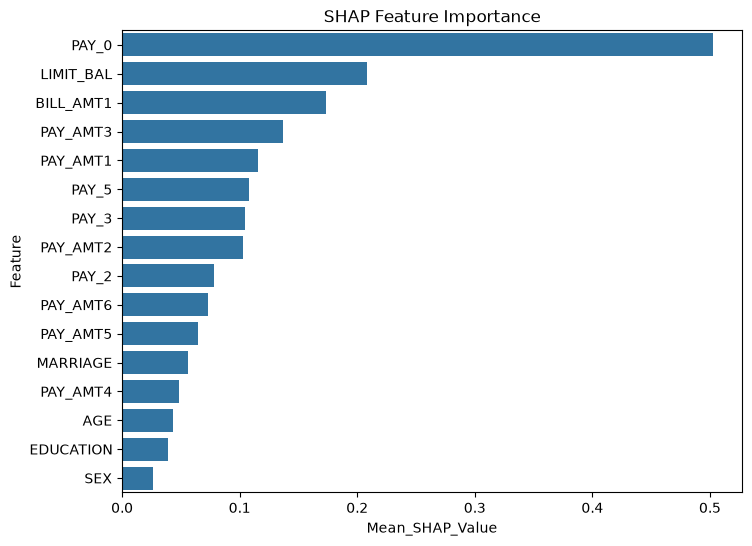

In [41]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=shap_importance,
    x="Mean_SHAP_Value",
    y="Feature"
)
plt.title(
    "SHAP Feature Importance"
)
plt.show()


**Top 15 Features**


In [42]:
final_features = (
    shap_importance
    .head(15)["Feature"]
    .tolist()
)
final_features

['PAY_0',
 'LIMIT_BAL',
 'BILL_AMT1',
 'PAY_AMT3',
 'PAY_AMT1',
 'PAY_5',
 'PAY_3',
 'PAY_AMT2',
 'PAY_2',
 'PAY_AMT6',
 'PAY_AMT5',
 'MARRIAGE',
 'PAY_AMT4',
 'AGE',
 'EDUCATION']

**Create Final Dataset**


In [43]:
X_train_final = X_train_B[
    final_features
]
X_test_final = X_test_B[
    final_features
]

**Final Feature Count**


In [44]:
print(
    "Final number of features:",
    X_train_final.shape[1]
)

Final number of features: 15


## Stage 3: LightGBM With Final 15 Features
The final LightGBM model is trained using only the 15 features selected
through SHAP feature importance ranking.
This stage represents the final feature set used for model benchmarking.

In [45]:
lgbm_final_stage = LGBMClassifier(
    random_state=RANDOM_STATE
)
lgbm_final_stage.fit(
    X_train_final,
    y_train
)


[LightGBM] [Info] Number of positive: 4645, number of negative: 16355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1965
[LightGBM] [Info] Number of data points in the train set: 21000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221190 -> initscore=-1.258742
[LightGBM] [Info] Start training from score -1.258742


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


**final auc calulation**

In [46]:
train_prob_final = lgbm_final_stage.predict_proba(
    X_train_final
)[:,1]
test_prob_final = lgbm_final_stage.predict_proba(
    X_test_final
)[:,1]
train_auc_final = roc_auc_score(
    y_train,
    train_prob_final
)
test_auc_final = roc_auc_score(
    y_test,
    test_prob_final
)
print("Final Stage Train AUC:",train_auc_final)
print("Final Stage Test AUC:",test_auc_final)

Final Stage Train AUC: 0.8817073219692644
Final Stage Test AUC: 0.7745627545383817


**final stage**

In [47]:
stage_C_result = pd.DataFrame({
    "Stage":[
        "After SHAP (Final 15 Features)"
    ],
    "Number of Features": [
        X_train_final.shape[1]
    ],
    "Train AUC": [
        train_auc_final
    ],
    "Test AUC": [
        test_auc_final
    ]
})
stage_results = pd.concat(
    [
        stage_results,
        stage_C_result
    ],
    ignore_index=True
)
stage_results

,Stage,Number of Features,Train AUC,Test AUC
0,Original Features,23,0.889521,0.776609
1,After Correlation Filter,16,0.883151,0.774006
2,After IV Filter,16,0.883151,0.774006
3,After SHAP (Final 15 Features),15,0.881707,0.774563


**plot auc**

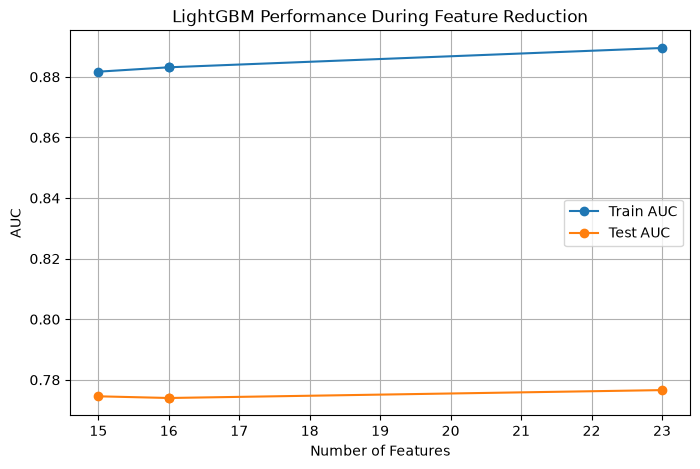

In [48]:
plt.figure(figsize=(8,5))
plt.plot(
    stage_results["Number of Features"],
    stage_results["Train AUC"],
    marker="o",
    label="Train AUC"
)
plt.plot(
    stage_results["Number of Features"],
    stage_results["Test AUC"],
    marker="o",
    label="Test AUC"
)
plt.xlabel(
    "Number of Features"
)
plt.ylabel(
    "AUC"
)
plt.title(
    "LightGBM Performance During Feature Reduction"
)
plt.legend()
plt.grid()
plt.show()

## Final Model Benchmarking
The final 15 features selected by SHAP are used to train and tune
multiple classification algorithms.
Hyperparameter tuning is performed using GridSearchCV with 5-fold
cross-validation and AUC as the optimization metric.


define model and parametres


In [49]:
#we create a dictionary(container) that stores each machine learning model and its hyperparameter values for tuning."
models_params = {
    "Logistic Regression": (
        LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000
        ),
        {
            "C": [0.01, 0.1, 1, 10] # controls regularization strength
        }
    ),
    "LightGBM": (
        LGBMClassifier(
            random_state=RANDOM_STATE
        ),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5]
        }
    ),
    "CatBoost": (
        CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=0
        ),
        {
            "n_estimators": [100, 200],
            "max_depth": [4, 6],
            "learning_rate": [0.05, 0.1]
        }
    ),
    "XGBoost": (
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss"
        ),
        {
            "n_estimators": [100, 200],
            "max_depth": [3,5],
            "learning_rate": [0.05,0.1]
                }
    ),
    "AdaBoost": (
        AdaBoostClassifier(
            random_state=RANDOM_STATE
        ),
        {
            "n_estimators": [50,100],
            "learning_rate": [0.05,0.1]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(
            random_state=RANDOM_STATE
        ),
        {
            "n_estimators": [100,200],
            "max_depth": [5,10,None]
        }
    )
}

**Run for all models**

In [50]:
#create an empty dictionary to store the best tuned model from each algorithm.
best_models = {}
for name, (model, params) in models_params.items():
    print(
        "Tuning:",
        name
    )
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring="auc",
        cv=5,
        n_jobs=-1
    )
    grid.fit(
        X_train_final,
        y_train
    )
    best_models[name] = grid.best_estimator_ #we save the best-performing model for each algorithm.
print("Best Parameters:",grid.best_params_) #prints the best hyperparameter values selected by GridSearchCV
print("Best CV AUC:", grid.best_score_) #highest average AUC score achieved during 5-fold cross-validation
 
    

Tuning: Logistic Regression
Tuning: LightGBM
[LightGBM] [Info] Number of positive: 4645, number of negative: 16355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001480 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1965
[LightGBM] [Info] Number of data points in the train set: 21000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221190 -> initscore=-1.258742
[LightGBM] [Info] Start training from score -1.258742
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

## Evaluation of Tuned Models
Each optimized model is retrained using the full training set and
evaluated on both training and testing data.
AUC is used as the main metric because it evaluates the ability
of the model to distinguish between default and non-default customers.


In [51]:
#We create an empty list to store the results of all models.
benchmark_results = []
#We go through each best tuned model one by one
for name, model in best_models.items(): 
    # Predictions on training data
    train_probability = model.predict_proba(
        X_train_final
    )[:,1]
    # Predictions on testing data
    test_probability = model.predict_proba(
        X_test_final
    )[:,1]
    # Class predictions
    test_prediction = model.predict(
        X_test_final
    )
    # measure how well the model separates default and non-default customers on training data
    train_auc = roc_auc_score(
        y_train,
        train_probability
    )
    #We measure the model performance on unseen test data.
    test_auc = roc_auc_score(
        y_test,
        test_probability
    )
    precision = precision_score(
        y_test,
        test_prediction
    )
    recall = recall_score(
        y_test,
        test_prediction
    )
    f1 = f1_score(
        y_test,
        test_prediction
    )
    benchmark_results.append(
        [
            name,
            train_auc,
            test_auc,
            precision,
            recall,
            f1
        ]
    )

 

**final comparsion**

In [52]:
benchmark_df = pd.DataFrame(
    benchmark_results,
    columns=[
        "Model",
        "Train AUC",
        "Test AUC",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)
benchmark_df.sort_values(
    by="Test AUC",
    ascending=False
)


,Model,Train AUC,Test AUC,Precision,Recall,F1 Score
2,CatBoost,0.801699,0.780101,0.659028,0.361125,0.466580
1,LightGBM,0.817876,0.776749,0.665112,0.358112,0.465557
3,XGBoost,0.815024,0.776412,0.660075,0.352084,0.459220
5,Random Forest,0.857244,0.774258,0.662890,0.352587,0.460328
4,AdaBoost,0.773408,0.761787,0.681967,0.313410,0.429456
0,Logistic Regression,0.724401,0.712429,0.693295,0.244098,0.361070


In [54]:
best_model_result = benchmark_df.loc[
    benchmark_df["Test AUC"].idxmax()
]
best_model_result

Model        CatBoost
Train AUC    0.801699
Test AUC     0.780101
Precision    0.659028
Recall       0.361125
F1 Score      0.46658
Name: 2, dtype: object

**test auc comparsion plot**

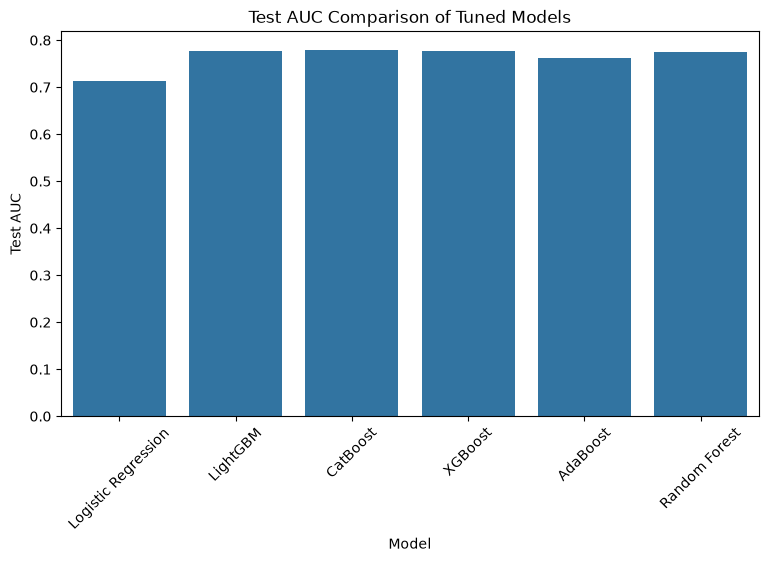

In [55]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=benchmark_df,
    x="Model",
    y="Test AUC"
)
plt.xticks(
    rotation=45
)
plt.title(
    "Test AUC Comparison of Tuned Models"
)
plt.ylabel(
    "Test AUC"
)
plt.show()

# Final Results Summary
## Feature Selection Impact
The original dataset contained 23 features
The sequential feature selection pipeline reduced the feature space through
three stages:
1. Correlation Filter:
   - Removed highly correlated features.
2. Information Value Filter:
   - Removed features with no predictive power.
3. SHAP Feature Ranking:
   - Selected the top 15 most important features.
The performance of LightGBM was evaluated after each stage using
Train AUC and Test AUC.

In [56]:
stage_results

,Stage,Number of Features,Train AUC,Test AUC
0,Original Features,23,0.889521,0.776609
1,After Correlation Filter,16,0.883151,0.774006
2,After IV Filter,16,0.883151,0.774006
3,After SHAP (Final 15 Features),15,0.881707,0.774563


In [57]:
benchmark_df.sort_values(
    by="Test AUC",
    ascending=False
)


,Model,Train AUC,Test AUC,Precision,Recall,F1 Score
2,CatBoost,0.801699,0.780101,0.659028,0.361125,0.466580
1,LightGBM,0.817876,0.776749,0.665112,0.358112,0.465557
3,XGBoost,0.815024,0.776412,0.660075,0.352084,0.459220
5,Random Forest,0.857244,0.774258,0.662890,0.352587,0.460328
4,AdaBoost,0.773408,0.761787,0.681967,0.313410,0.429456
0,Logistic Regression,0.724401,0.712429,0.693295,0.244098,0.361070


# Conclusion
This project developed a machine learning pipeline for predicting credit
card default probability.
The original 23 features were reduced to the final 15 features using a
sequential feature selection process consisting of correlation filtering,
Information Value filtering, and SHAP-based feature ranking.
The LightGBM model performance was evaluated at each feature reduction stage
using Train AUC and Test AUC. The results showed the effect of reducing
feature dimensionality while maintaining predictive performance.
    After selecting the final 15 features, six classification algorithms were
optimized using hyperparameter tuning and compared:
- Logistic Regression
- LightGBM
- CatBoost
- XGBoost
- AdaBoost
- Random Forest

The best-performing model was CatBoost with a Test AUC of
0.780101.
Overall, the feature selection pipeline improved model efficiency by
reducing unnecessary features while preserving important predictive
information. The final model can be used as a decision-support tool for
identifying customers with higher default risk.

## Final Pipeline Verification
Before submission, we verify that the feature selection pipeline produced
the expected number of features and that training/testing datasets remain
consistent.


In [58]:
print("Original features:")
print(X_train.shape[1])
print("\nAfter Correlation Filter:")
print(X_train_A.shape[1])
print("\nAfter IV Filter:")
print(X_train_B.shape[1])
print("\nFinal Selected Features:")
print(X_train_final.shape[1])

Original features:
23

After Correlation Filter:
16

After IV Filter:
16

Final Selected Features:
15


In [59]:
final_features

['PAY_0',
 'LIMIT_BAL',
 'BILL_AMT1',
 'PAY_AMT3',
 'PAY_AMT1',
 'PAY_5',
 'PAY_3',
 'PAY_AMT2',
 'PAY_2',
 'PAY_AMT6',
 'PAY_AMT5',
 'MARRIAGE',
 'PAY_AMT4',
 'AGE',
 'EDUCATION']

In [60]:
print(
    X_train_final.isnull().sum().sum()
)
print(
    X_test_final.isnull().sum().sum()
)


0
0


In [61]:
#Check Train/Test Feature Matching
print(
    X_train_final.columns.equals(
        X_test_final.columns
    )
)


True


In [62]:
#save final result
stage_results.to_csv(
    "feature_selection_results.csv",
    index=False
)
benchmark_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

In [63]:
#Save Final Best Model
import joblib
best_model_name = benchmark_df.loc[
    benchmark_df["Test AUC"].idxmax(),
    "Model"
]
best_model = best_models[
    best_model_name
]
joblib.dump(
    best_model,
    "best_credit_default_model.pkl"
)
joblib.dump(
    final_features,
    "final_features.pkl"
)

['final_features.pkl']

In [64]:
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [65]:
df.shape


(30000, 25)

In [66]:
X.shape


(30000, 23)

In [67]:
y.value_counts()


default payment next month
0    23364
1     6636
Name: count, dtype: int64

In [68]:
stage_results

,Stage,Number of Features,Train AUC,Test AUC
0,Original Features,23,0.889521,0.776609
1,After Correlation Filter,16,0.883151,0.774006
2,After IV Filter,16,0.883151,0.774006
3,After SHAP (Final 15 Features),15,0.881707,0.774563


In [69]:
final_features

['PAY_0',
 'LIMIT_BAL',
 'BILL_AMT1',
 'PAY_AMT3',
 'PAY_AMT1',
 'PAY_5',
 'PAY_3',
 'PAY_AMT2',
 'PAY_2',
 'PAY_AMT6',
 'PAY_AMT5',
 'MARRIAGE',
 'PAY_AMT4',
 'AGE',
 'EDUCATION']

In [70]:
benchmark_df

,Model,Train AUC,Test AUC,Precision,Recall,F1 Score
0,Logistic Regression,0.724401,0.712429,0.693295,0.244098,0.361070
1,LightGBM,0.817876,0.776749,0.665112,0.358112,0.465557
2,CatBoost,0.801699,0.780101,0.659028,0.361125,0.466580
3,XGBoost,0.815024,0.776412,0.660075,0.352084,0.459220
4,AdaBoost,0.773408,0.761787,0.681967,0.313410,0.429456
5,Random Forest,0.857244,0.774258,0.662890,0.352587,0.460328


In [71]:
#best model
benchmark_df.loc[
    benchmark_df["Test AUC"].idxmax()
]

Model        CatBoost
Train AUC    0.801699
Test AUC     0.780101
Precision    0.659028
Recall       0.361125
F1 Score      0.46658
Name: 2, dtype: object

The feature selection pipeline successfully reduced the number of
features from 23 to 15.
The correlation filter removed redundant features with high Pearson
correlation values.
The Information Value filter removed features with no predictive
relationship with the target variable.
Finally, SHAP-based ranking identified the most influential features
for predicting credit default.
The LightGBM AUC results show whether the reduction maintained,
improved, or decreased predictive performance.


Among the six tested algorithms, the model with the highest Test AUC
achieved the strongest ability to distinguish between default and
non-default customers.
This indicates that this algorithm captured the relationship between
customer characteristics and default probability more effectively.


The difference between Train AUC and Test AUC indicates how well the
model generalizes.
A very large difference suggests overfitting, while similar values
indicate better generalization to unseen data.

AUC was selected as the main evaluation metric because the problem is
a binary classification task and the classes may not be perfectly
balanced.
AUC measures how well the model ranks customers according to their
probability of default.